# Fault Diagnosis for ADMIRE Model

## 0. Setup

In [11]:
import jax
import jax.numpy as jnp
import immrax as irx
print(jax.devices())

[CpuDevice(id=0)]


In [12]:
import os, sys
sys.path.append("/home/user/output_feedback/nhholyap/examples/")
from functools import partial
from jax import jit, lax, vmap

The actuator-linear ADMIRE model has the following inputs:

u = [right canard, 

    left canard, 

    right outboard elevon, 

    right inboard elevon,

    left inboard elevon,

    left outboard elevon, 

    rudder, 

    flaps,

    yaw thrust vectoring, 
    
    pitch thrust vectoring]

In [13]:
from admire import AdmireNineDoFLinAct
from faulty_car.interval_functions import overlap_size_lax, overlap_size
admire = AdmireNineDoFLinAct()
x0_admire = jnp.zeros(9)
x0_admire = x0_admire.at[0].set(343 * 0.3)  # Set the first joint to 1.0
x0_interval_admire = irx.icentpert(x0_admire, jnp.ones(9) * 0.01)
admire_embsys = irx.natemb(admire)
p_rc_fault = jnp.array([0., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
p_lc_fault = jnp.array([1., 0., 1., 1., 1., 1., 1., 1., 1., 1.])
p_roe_fault = jnp.array([1., 1., 0., 1., 1., 1., 1., 1., 1., 1.])
p_rie_fault = jnp.array([1., 1., 1., 0., 1., 1., 1., 1., 1., 1.])
p_lie_fault = jnp.array([1., 1., 1., 1., 0., 1., 1., 1., 1., 1.])
p_loe_fault = jnp.array([1., 1., 1., 1., 1., 0., 1., 1., 1., 1.])
p_rudder_fault = jnp.array([1., 1., 1., 1., 1., 1., 0., 1., 1., 1.])
p_flap_fault = jnp.array([1., 1., 1., 1., 1., 1., 1., 0., 1., 1.])
p_yaw_tv_fault = jnp.array([1., 1., 1., 1., 1., 1., 1., 1., 0., 1.]) #Full loss of yaw thrust vectoring
w_yaw_tv_fault = jnp.array([0., 0., 0., 0., 0., 0., 0., 0., 0.2, 0.]) #Yaw TV stuck at 0.2 rad
p_pitch_tv_fault = jnp.array([1., 1., 1., 1., 1., 1., 1., 1., 1., 0.])
p_no_fault = jnp.array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]) #No fault
p_nominal_ivl = irx.icentpert(p_no_fault, jnp.zeros_like(p_no_fault))
p_yaw_tv_ivl = irx.icentpert(p_yaw_tv_fault, jnp.zeros_like(p_yaw_tv_fault))
p_rudder_ivl = irx.icentpert(p_rudder_fault, jnp.zeros_like(p_rudder_fault))
dt = 0.1
num_steps = 10

## 1. Reachable Set Calculation on ADMIRE

In [14]:
print(p_yaw_tv_ivl.lower
    )

[1. 1. 1. 1. 1. 1. 1. 1. 0. 1.]


In [15]:
def dummy_u_map(t, x):
    return jnp.zeros(9)
x_lowers = []
x_uppers = []
x_ivl = x0_interval_admire
for _ in range(100):
    x_ivl = irx.ut2i(admire_embsys.f(
        0, 
        irx.i2ut(x_ivl),
        jnp.zeros(10),
        jnp.ones(10)
    )) * 0.01 + x_ivl
    x_lowers.append(x_ivl.lower)
    x_uppers.append(x_ivl.upper)
x_lowers_array = jnp.array(x_lowers)
x_uppers_array = jnp.array(x_uppers)

Plotting AoA

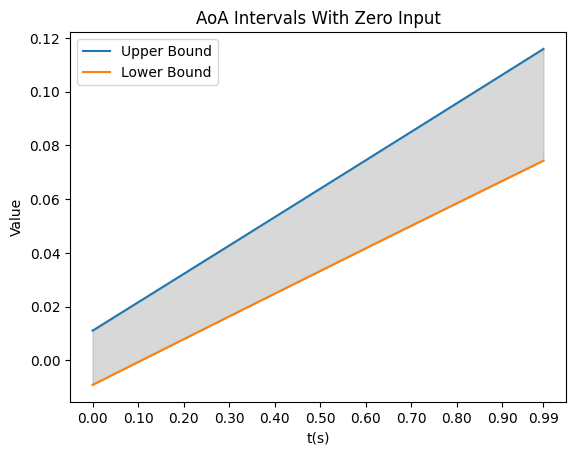

In [16]:
import matplotlib.pyplot as plt

plt.plot(x_uppers_array[:, 1], label='Upper Bound')
plt.plot(x_lowers_array[:, 1], label='Lower Bound')
plt.fill_between(range(len(x_uppers_array)), x_lowers_array[:, 1], x_uppers_array[:, 1], color='gray', alpha=0.3)
plt.xlabel('t(s)')
plt.ylabel('Value')
# Show only a few evenly spaced ticks (e.g., every 10th tick), and add the final point t=1
step = 10
ticks = list(range(0, len(x_uppers_array), step))
if ticks[-1] != len(x_uppers_array) - 1:
    ticks.append(len(x_uppers_array) - 1)
labels = [f"{i/100:.2f}" for i in ticks]
plt.xticks(ticks=ticks, labels=labels)
plt.legend()
plt.title('AoA Intervals With Zero Input')
plt.show()

## 2. Calculate Optimal Open Loop Separating Input

In [ ]:
def propagate_interval_euler_admire(x_ivl, u_ol, p_ivl, dt=0.01):
    return irx.ut2i(admire_embsys.f(
        0, 
        irx.i2ut(x_ivl),
        u_ol,
        p_ivl,
    )) * dt + x_ivl

def loss_ff_jax(u_ol, x_interval, p_nominal, p_actuator_fault, dt, num_steps=10):
    """
    Loss function for the open-loop control input.
    This function is designed to be JIT-compiled.
    """
    # Propagate the initial state through the system dynamics
    def nominal_step_fn(t, x_ivl):
        return propagate_interval_euler_admire(x_ivl, u_ol, p_nominal, dt=dt)
    def actuator_fault_step_fn(t, x_ivl):
        return propagate_interval_euler_admire(x_ivl, u_ol, p_actuator_fault, dt=dt)
    x_ivl_nominal = jax.lax.fori_loop(0, num_steps, nominal_step_fn, x_interval)
    x_ivl_actuator_fault = jax.lax.fori_loop(0, num_steps, actuator_fault_step_fn, x_interval)
    # Calculate the loss as the squared difference between the propagated state and the observer offset
    loss = overlap_size_lax(
        x_ivl_nominal, x_ivl_actuator_fault
    )
    
    return loss

def loss_ff_three_jax(u_ol, x_interval, p_nominal, p_fault1, p_fault2, dt, num_steps=10):
    """
    Loss function for the open-loop control input.
    This function is designed to be JIT-compiled.
    """
    # Propagate the initial state through the system dynamics
    def nominal_step_fn(t, x_ivl):
        return propagate_interval_euler_admire(x_ivl, u_ol, p_nominal, dt=dt)
    def actuator_fault_step_fn(t, x_ivl):
        return propagate_interval_euler_admire(x_ivl, u_ol, p_fault1, dt=dt)
    def fault2_step_fn(t, x_ivl):
        return propagate_interval_euler_admire(x_ivl, u_ol, p_fault2, dt=dt)
    x_ivl_nominal = jax.lax.fori_loop(0, num_steps, nominal_step_fn, x_interval)
    x_ivl_fault1 = jax.lax.fori_loop(0, num_steps, actuator_fault_step_fn, x_interval)
    x_ivl_fault2 = jax.lax.fori_loop(0, num_steps, actuator_fault_step_fn, x_interval)
    # Calculate the loss as the squared difference between the propagated state and the observer offset
    loss = overlap_size_lax(x_ivl_nominal, x_ivl_fault1) + overlap_size_lax(x_ivl_nominal, x_ivl_fault2) + overlap_size_lax(x_ivl_fault1, x_ivl_fault2)
    return loss

def loss_ff_slow(u_ol, x_interval, p_nominal, p_actuator_fault, dt, num_steps=100):
    x_ivl_nominal = x_interval
    x_ivl_actuator_fault = x_interval
    for i in range(num_steps):
        x_ivl_nominal = propagate_interval_euler_admire(x_ivl_nominal, u_ol, p_nominal, dt=dt)
        x_ivl_actuator_fault = propagate_interval_euler_admire(x_ivl_actuator_fault, u_ol, p_actuator_fault, dt=dt)
    return overlap_size(x_ivl_nominal, x_ivl_actuator_fault)

In [68]:
from faulty_car.interval_functions import overlap_size_lax
loss_grad = jax.grad(loss_ff_jax, argnums=0)
loss_3_grad = jax.grad(loss_ff_three_jax, argnums=0)
loss_slow = jax.grad(loss_ff_slow, argnums=0)
from jaxopt import LBFGSB
def calculate_optimal_open_loop_u(x_interval, p_nominal, p_actuator_fault, dt, num_steps=100):
    """
    Calculates the optimal open-loop control input `u` using a multi-start gradient descent.
    This entire function is designed to be JIT-compiled.
    """
    # This inner function performs one run of gradient descent from a random starting point.
    def find_optimal_u():
        learning_rate = 1e2
        num_gd_steps = 10

        u_initial = jnp.ones(admire.ulen) * 1e-2

        # # Define the body of the gradient descent loop
        def gradient_step(i, u_current):
            grad = loss_grad(u_current, x_interval, p_nominal, p_actuator_fault, dt, num_steps=num_steps)
            print(f"grad value: {grad}")
            return u_current - learning_rate * grad
        

        u_opt = jax.lax.fori_loop(0, num_gd_steps, gradient_step, u_initial)
    
        return u_opt#u_initial#u_opt


    return find_optimal_u()#batch_of_u_opts[best_run_index]

def calculate_optimal_open_loop_3_faults(x_interval, learning_rate, u_initial, p_nominal, p_fault1, p_fault2, dt, num_steps=100):
    num_gd_steps = 10
    # # Define the body of the gradient descent loop
    def gradient_step(i, u_current):
        grad = loss_3_grad(u_current, x_interval, p_nominal, p_fault1, p_fault2, dt, num_steps=num_steps)
        return u_current - learning_rate * grad
    

    u_opt = jax.lax.fori_loop(0, num_gd_steps, gradient_step, u_initial)

    return u_opt#u_initial#u_opt



def calculate_optimal_open_loop_u_slow(x_interval, p_nominal, p_actuator_fault, dt, num_steps=100):
    """
    Calculates the optimal open-loop control input `u` using a multi-start gradient descent.
    This entire function is designed to be JIT-compiled.
    """
    # This inner function performs one run of gradient descent from a random starting point.
    u_current = jnp.ones(admire.ulen) * 1e-2
    learning_rate = 1e1
    for i in range(10):
        grad = loss_slow(u_current, x_interval, p_nominal, p_actuator_fault, dt, num_steps=num_steps)
        print(f"grad value: {grad}")
        u_current -= learning_rate * grad
    return u_current

JIT u optimization

In [42]:
jit_calculate_optimal_open_loop_u = jit(partial(
    calculate_optimal_open_loop_u,
    p_nominal=p_nominal_ivl,
    p_actuator_fault=p_yaw_tv_ivl,
    dt=dt,
    num_steps=num_steps
))

In [69]:
jit_calculate_optimal_open_loop_u_3faults = jit(partial(
    calculate_optimal_open_loop_3_faults,
    p_nominal=p_nominal_ivl,
    p_fault1=p_yaw_tv_ivl,
    p_fault2=p_rudder_ivl,
    dt=dt,
    num_steps=num_steps
))

In [58]:
jax.block_until_ready(jit_calculate_optimal_open_loop_u(x0_interval_admire))

Array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],      dtype=float32)

In [70]:
jax.block_until_ready(
    jit_calculate_optimal_open_loop_u_3faults(
        x0_interval_admire, 
        1e8,
        jnp.array([0., 0., 0., 0., 0., 0., 0.01, 0., 0.01, 0.])
        )
        )

Array([-1.3950069e-03,  8.6548354e-04,  1.4616566e-03,  8.6368062e-04,
        1.3072388e-06, -9.4202574e-04,  4.4907294e-03,  7.8712765e-06,
        9.9999998e-03,  2.8550818e-03], dtype=float32)

In [56]:
%timeit u = jit_calculate_optimal_open_loop_u(x0_interval_admire)

485 ms ± 612 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
u = jit_calculate_optimal_open_loop_u_3faults(
    x0_interval_admire, 
    1e8, 
    jnp.ones(admire.ulen) * 0.01
    # jnp.array([0., 0., 0., 0., 0., 0., 0.1, 0., 0.01, 0.])
)
print(u)
print(loss_ff_three_jax(u, x0_interval_admire, p_nominal_ivl, p_yaw_tv_ivl, p_rudder_ivl, dt=0.1, num_steps=10))

[-3.5109497e-03  2.9042813e-03  7.8931591e-03  5.7872552e-03
 -4.6737613e-03 -7.2356877e-03  8.4799595e-02  8.8746510e-06
  9.9999998e-03  3.4487129e-03]
1.5413988e-12


In [95]:
import time
total_t = 0.0
for _ in range(100):
    t0 = time.time()
    u = jit_calculate_optimal_open_loop_u(x0_interval_admire)
    t1 = time.time()
    total_t += t1 - t0
print(f"Average runtime: {total_t / 100:.4f}s")

Average runtime: 0.4769s


In [106]:
u = jit_calculate_optimal_open_loop_u(x0_interval_admire)

In [48]:
print(u)

[0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]


In [48]:
loss_ff_three_jax(u_ol=u, x_interval=x0_interval_admire, p_nominal=p_nominal_ivl, p_fault1=p_yaw_tv_ivl, p_fault2=p_rudder_ivl, dt=.1)

Array(8.738342e-13, dtype=float32, weak_type=True)

In [50]:
loss_ff_jax(u_ol=jnp.ones(admire.ulen) * 1e-2, x_interval=x0_interval_admire, p_nominal=p_nominal_ivl, p_actuator_fault=p_yaw_tv_ivl, dt=.1)

Array(0., dtype=float32, weak_type=True)

In [25]:
loss_ff_slow(u_ol=jnp.ones(admire.ulen) * 1e-2, x_interval=x0_interval_admire, p_nominal=p_nominal_ivl, p_actuator_fault=p_yaw_tv_ivl, dt=.1)

[-1.05202119e+04            -inf            -inf -9.52692106e-02
 -9.06536341e-01 -1.23516284e-01            -inf -4.74900055e+00
            -inf]
[ 5.4849400e+05            inf            inf  4.5427904e-01
 -6.8803322e-01  3.3771738e-01            inf  2.1567526e+00
            inf]


Array(inf, dtype=float32)

### 2.1.2 Plots of embsys trajectory and embsys.F under Input

It was noticed that applying u=ones(10) * 0.01 will cause speed, AoA and Sideslip angles to blow up. To investigate what is happening, some plots are being produced.

In [55]:
# Modification of propagate_interval_euler to visualize embsys upper and lower on sys's dynamics.
import copy
def plot_intervals_euler_admire(u_ol, x_interval, p_nominal, p_actuator_fault, p_fault2=None, dt=0.1, num_steps=100):
    """
    Propagates two interval scenarios (nominal and fault) using Euler's method,
    stores the history of state and derivative intervals, and plots the results.

    This function breaks down the propagation step to explicitly capture the
    derivatives calculated by `admire_embsys.f`. It then plots the evolution
    of both state and derivative intervals for each of the 9 dimensions.

    Args:
        u_ol: Open-loop control input.
        x_interval (immrax.Interval): Initial interval for the state vector (9-dim).
        p_nominal (jnp.array): Nominal parameter set.
        p_actuator_fault (jnp.array): Faulty parameter set.
        dt (float): Time step for the Euler integration.
        num_steps (int): The number of steps to simulate.

    Returns:
        dict: A dictionary containing the lists of historical intervals for
              both scenarios. Keys are: "nominal_states", "fault_states",
              "nominal_derivatives", "fault_derivatives".
    """
    # Initialize state variables
    x_ivl_nominal = x_interval
    x_ivl_fault = x_interval

    # Lists to store the history of intervals
    nominal_state_history = [x_ivl_nominal]
    fault_state_history = [x_ivl_fault]
    if p_fault2 is not None:
        x_ivl_fault2 = copy.deepcopy(x_interval)
        fault2_state_history = [x_ivl_fault2]
        fault2_derivative_history = []
    nominal_derivative_history = []
    fault_derivative_history = []
    
    print(f"Starting simulation for {num_steps} steps...")

    # Main simulation loop
    for i in range(num_steps):
        # --- 1. Nominal Scenario Propagation ---
        
        # a. Calculate derivatives in upper-triangular form
        derivatives_nominal_ut = admire_embsys.f(0, irx.i2ut(x_ivl_nominal), u_ol, p_nominal)
        # b. Convert derivatives to an interval and save it
        derivative_ivl_nominal = irx.ut2i(derivatives_nominal_ut)
        nominal_derivative_history.append(derivative_ivl_nominal)
        # c. Apply Euler step and save the new state interval
        x_ivl_nominal = (derivative_ivl_nominal * dt) + x_ivl_nominal
        nominal_state_history.append(x_ivl_nominal)

        # --- 2. Actuator Fault Scenario Propagation ---
        # NOTE: Following the original logic, the "fault" state is propagated
        # with the "nominal" parameters.

        # a. Calculate derivatives in upper-triangular form
        derivatives_fault_ut = admire_embsys.f(0, irx.i2ut(x_ivl_fault), u_ol, p_actuator_fault)
        # b. Convert derivatives to an interval and save it
        derivative_ivl_fault = irx.ut2i(derivatives_fault_ut)
        fault_derivative_history.append(derivative_ivl_fault)
        # c. Apply Euler step and save the new state interval
        x_ivl_fault = (derivative_ivl_fault * dt) + x_ivl_fault
        fault_state_history.append(x_ivl_fault)

        if p_fault2 is not None:
            # a. Calculate derivatives in upper-triangular form
            derivatives_fault2_ut = admire_embsys.f(0, irx.i2ut(x_ivl_fault2), u_ol, p_fault2)
            # b. Convert derivatives to an interval and save it
            derivative_ivl_fault2 = irx.ut2i(derivatives_fault2_ut)
            fault2_derivative_history.append(derivative_ivl_fault2)
            # c. Apply Euler step and save the new state interval
            x_ivl_fault2 = (derivative_ivl_fault2 * dt) + x_ivl_fault2
            fault2_state_history.append(x_ivl_fault2)

    print("Simulation finished. Preparing data for plotting...")

    # --- Data Preparation for Plotting ---
    # Create time axes
    time_axis_states = jnp.arange(num_steps + 1) * dt  # For states (t=0 to t_final)
    time_axis_derivs = jnp.arange(num_steps) * dt      # For derivatives (t=0 to t_final-dt)

    # Stack interval histories into JAX arrays for efficient indexing
    # Shape: (num_steps, 9)
    nominal_derivs_lower = jnp.stack([ivl.lower for ivl in nominal_derivative_history])
    nominal_derivs_upper = jnp.stack([ivl.upper for ivl in nominal_derivative_history])
    fault_derivs_lower = jnp.stack([ivl.lower for ivl in fault_derivative_history])
    fault_derivs_upper = jnp.stack([ivl.upper for ivl in fault_derivative_history])
    
    # Shape: (num_steps + 1, 9)
    nominal_states_lower = jnp.stack([ivl.lower for ivl in nominal_state_history])
    nominal_states_upper = jnp.stack([ivl.upper for ivl in nominal_state_history])
    fault_states_lower = jnp.stack([ivl.lower for ivl in fault_state_history])
    fault_states_upper = jnp.stack([ivl.upper for ivl in fault_state_history])

    if p_fault2 is not None:
        fault2_derivs_lower = jnp.stack([ivl.lower for ivl in fault2_derivative_history])
        fault2_derivs_upper = jnp.stack([ivl.upper for ivl in fault2_derivative_history]) 
        fault2_states_lower = jnp.stack([ivl.lower for ivl in fault2_state_history])
        fault2_states_upper = jnp.stack([ivl.upper for ivl in fault2_state_history])

    print("Generating plots...")
    # --- Plotting ---
    num_dims = x_interval.lower.shape[0]
    dim_names = ["Velocity (m/s)", "AoA (rad)", "Sideslip Angle (rad)", "roll rate (rad/s)", "pitch rate (rad/s)", 
                 "yaw rate (rad/s)", "heading angle (rad)", "pitch angle (rad)", "roll angle (rad)"]
    for dim in range(num_dims):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
        fig.suptitle(f'Interval Evolution for {dim_names[dim]}', fontsize=16)

        # Plot 1: Derivatives
        ax1.set_title("Derivative Intervals (dx/dt)")
        ax1.plot(time_axis_derivs, nominal_derivs_lower[:, dim], color='blue', ls='-', label='Nominal Lower')
        ax1.plot(time_axis_derivs, nominal_derivs_upper[:, dim], color='blue', ls='-')
        ax1.fill_between(time_axis_derivs, nominal_derivs_lower[:, dim], nominal_derivs_upper[:, dim], 
                         color='blue', alpha=0.2, label='Nominal Interval')

        ax1.plot(time_axis_derivs, fault_derivs_lower[:, dim], color='red', ls='--', label='Fault Lower')
        ax1.plot(time_axis_derivs, fault_derivs_upper[:, dim], color='red', ls='--')
        ax1.fill_between(time_axis_derivs, fault_derivs_lower[:, dim], fault_derivs_upper[:, dim], 
                         color='red', alpha=0.2, label='Fault Interval')
        

        # Plot 2: Computed State Intervals
        ax2.set_title("State Intervals (x)")
        ax2.plot(time_axis_states, nominal_states_lower[:, dim], color='blue', ls='-')
        ax2.plot(time_axis_states, nominal_states_upper[:, dim], color='blue', ls='-')
        ax2.fill_between(time_axis_states, nominal_states_lower[:, dim], nominal_states_upper[:, dim], 
                         color='blue', alpha=0.2, label='Nominal Interval')

        ax2.plot(time_axis_states, fault_states_lower[:, dim], color='red', ls='--')
        ax2.plot(time_axis_states, fault_states_upper[:, dim], color='red', ls='--')
        ax2.fill_between(time_axis_states, fault_states_lower[:, dim], fault_states_upper[:, dim], 
                         color='red', alpha=0.2, label='Fault Interval')
        

        if p_fault2 is not None:
            ax1.plot(time_axis_derivs, fault2_derivs_lower[:, dim], color='yellow', ls='--', label='Fault Lower')
            ax1.plot(time_axis_derivs, fault2_derivs_upper[:, dim], color='yellow', ls='--')
            ax1.fill_between(time_axis_derivs, fault2_derivs_lower[:, dim], fault2_derivs_upper[:, dim], 
                            color='yellow', alpha=0.2, label='Fault Interval')
            ax2.plot(time_axis_states, fault2_states_lower[:, dim], color='yellow', ls='--')
            ax2.plot(time_axis_states, fault2_states_upper[:, dim], color='yellow', ls='--')
            ax2.fill_between(time_axis_states, fault2_states_lower[:, dim], fault2_states_upper[:, dim], 
                            color='yellow', alpha=0.2, label='Fault Interval')


        ax1.set_ylabel('Derivative Value')
        ax1.legend()
        ax1.grid(True, linestyle=':')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('State Value')
        ax2.legend()
        ax2.grid(True, linestyle=':')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    # Return the collected data
    return {
        "nominal_states": nominal_state_history,
        "fault_states": fault_state_history,
        "nominal_derivatives": nominal_derivative_history,
        "fault_derivatives": fault_derivative_history,
    }



### 2.2. Plot Reachable Sets Under Separating Inputs

Starting simulation for 10 steps...
Simulation finished. Preparing data for plotting...
Generating plots...


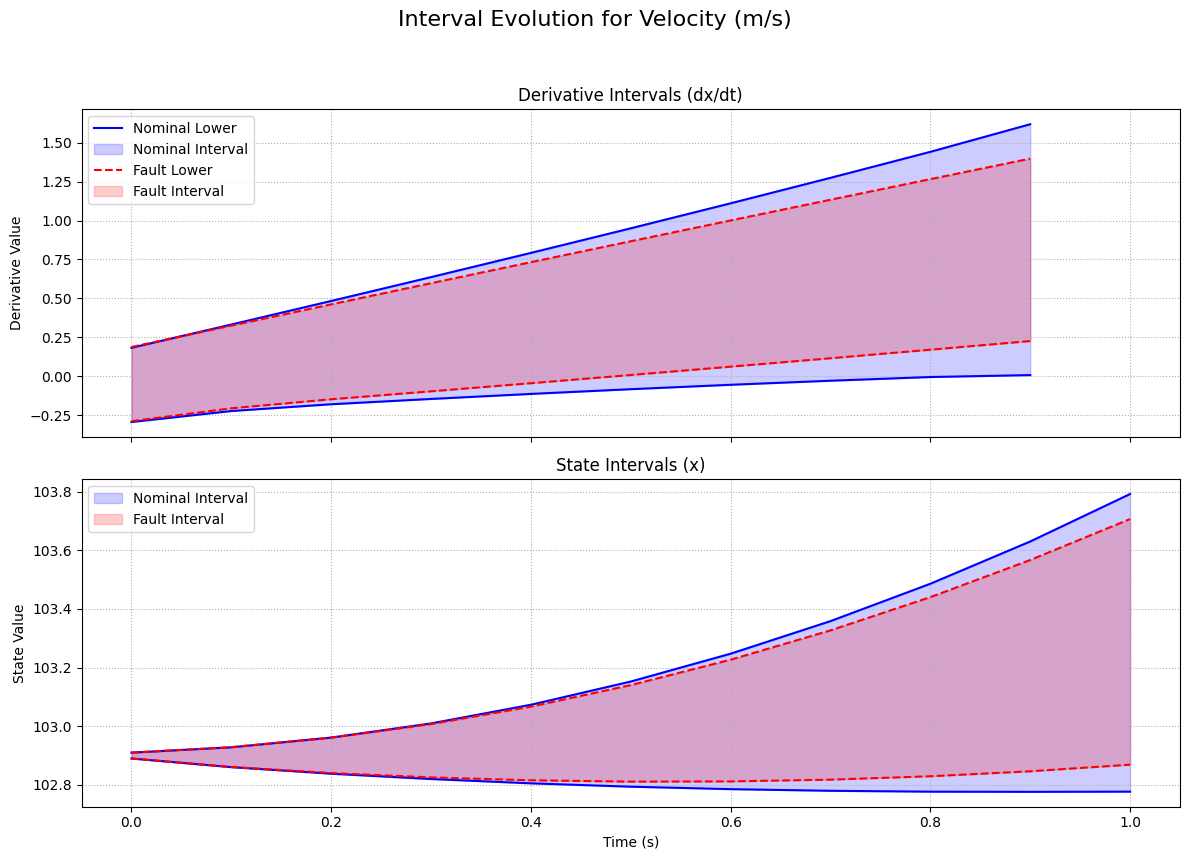

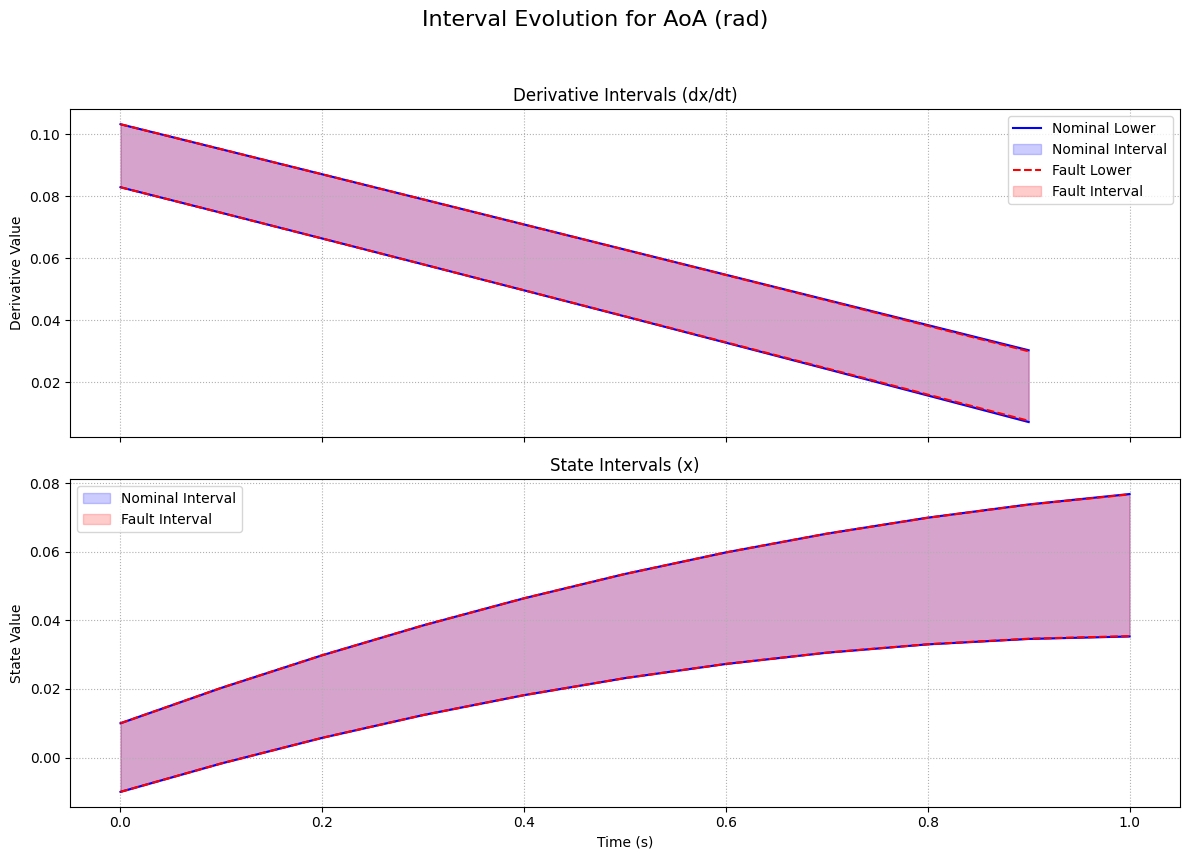

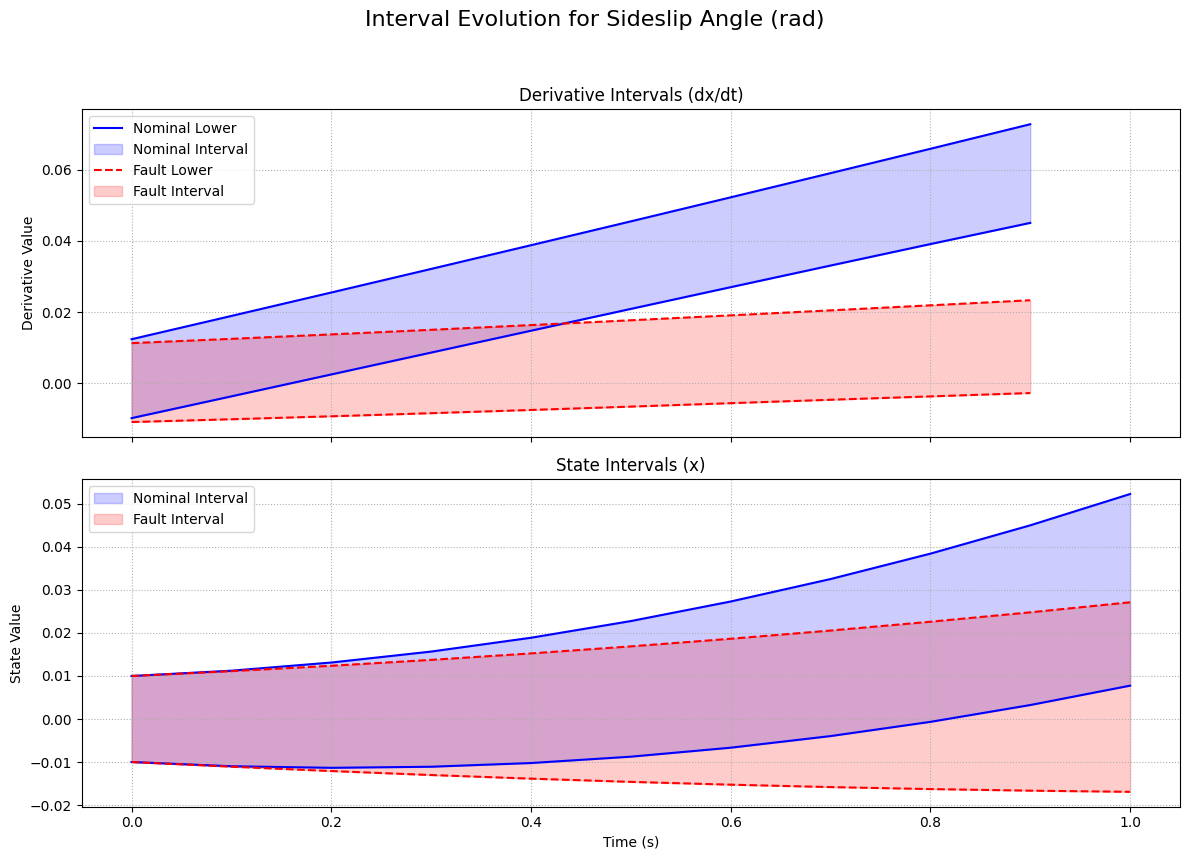

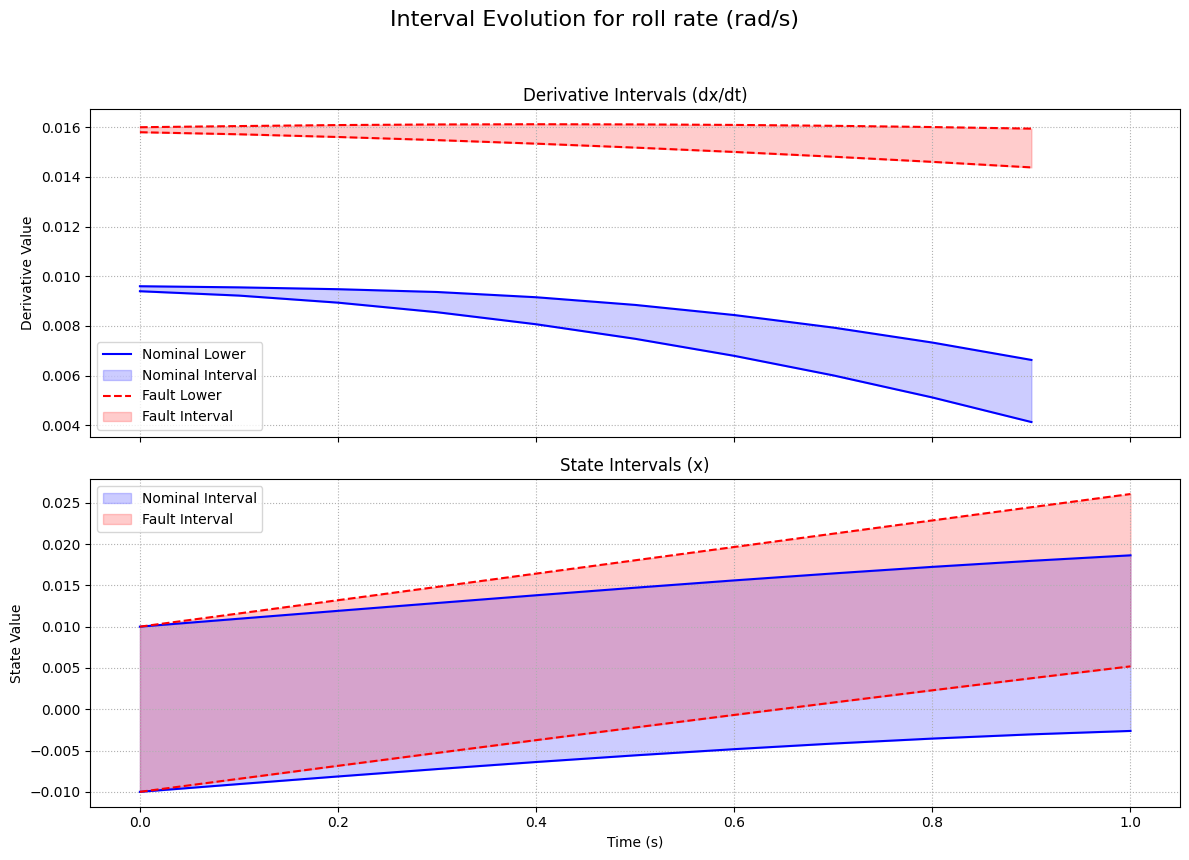

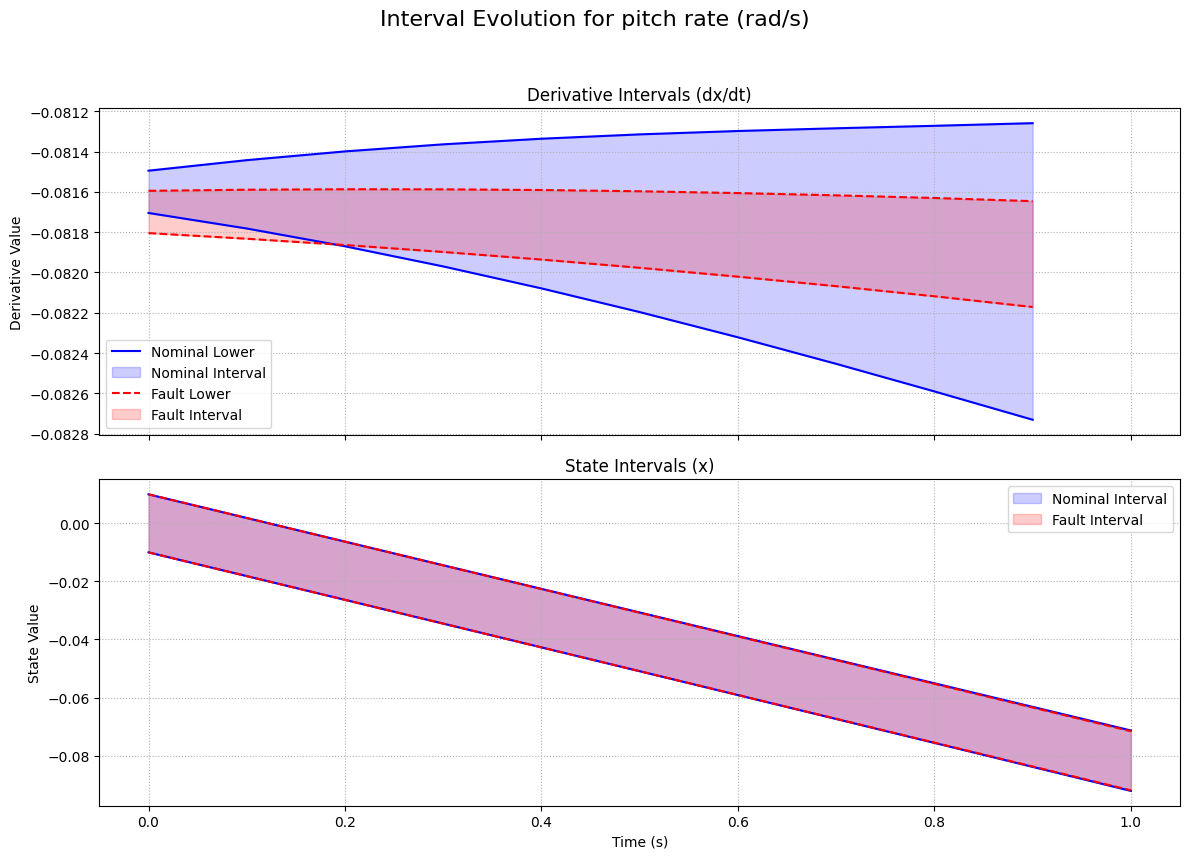

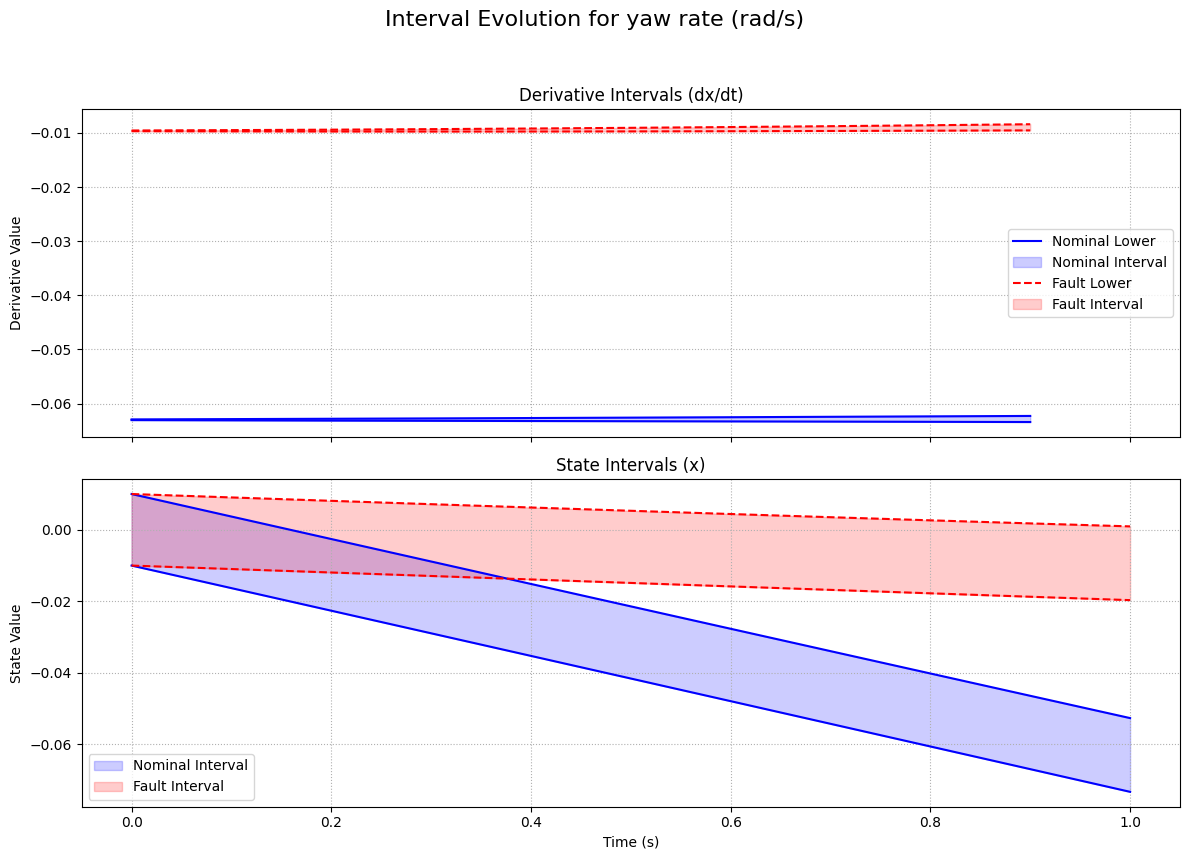

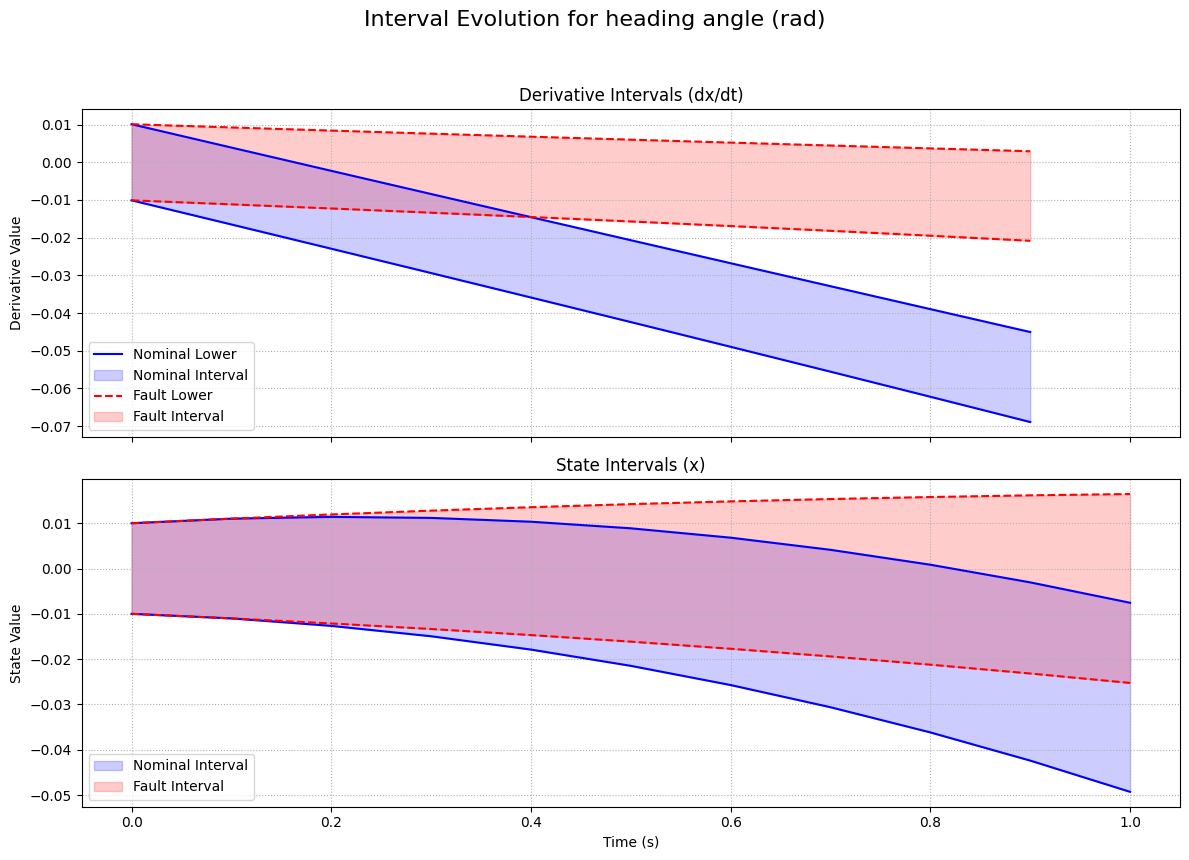

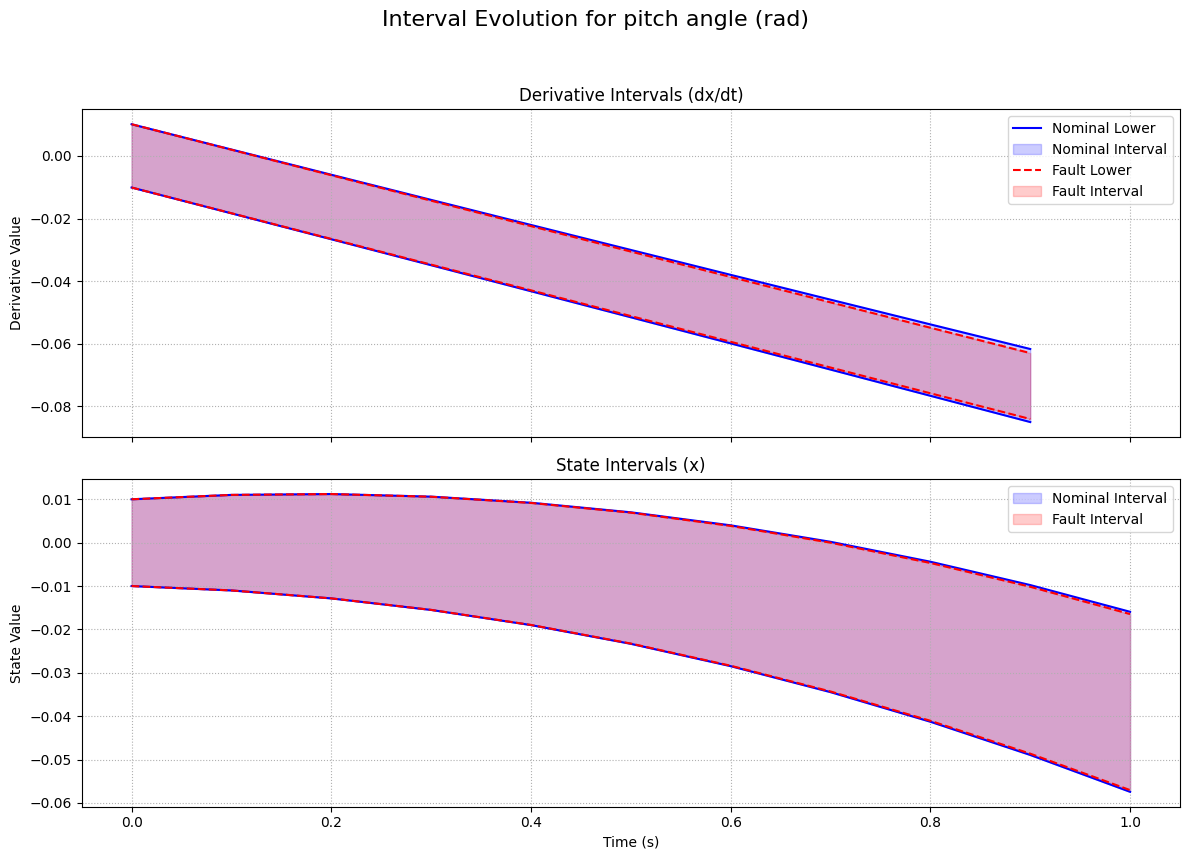

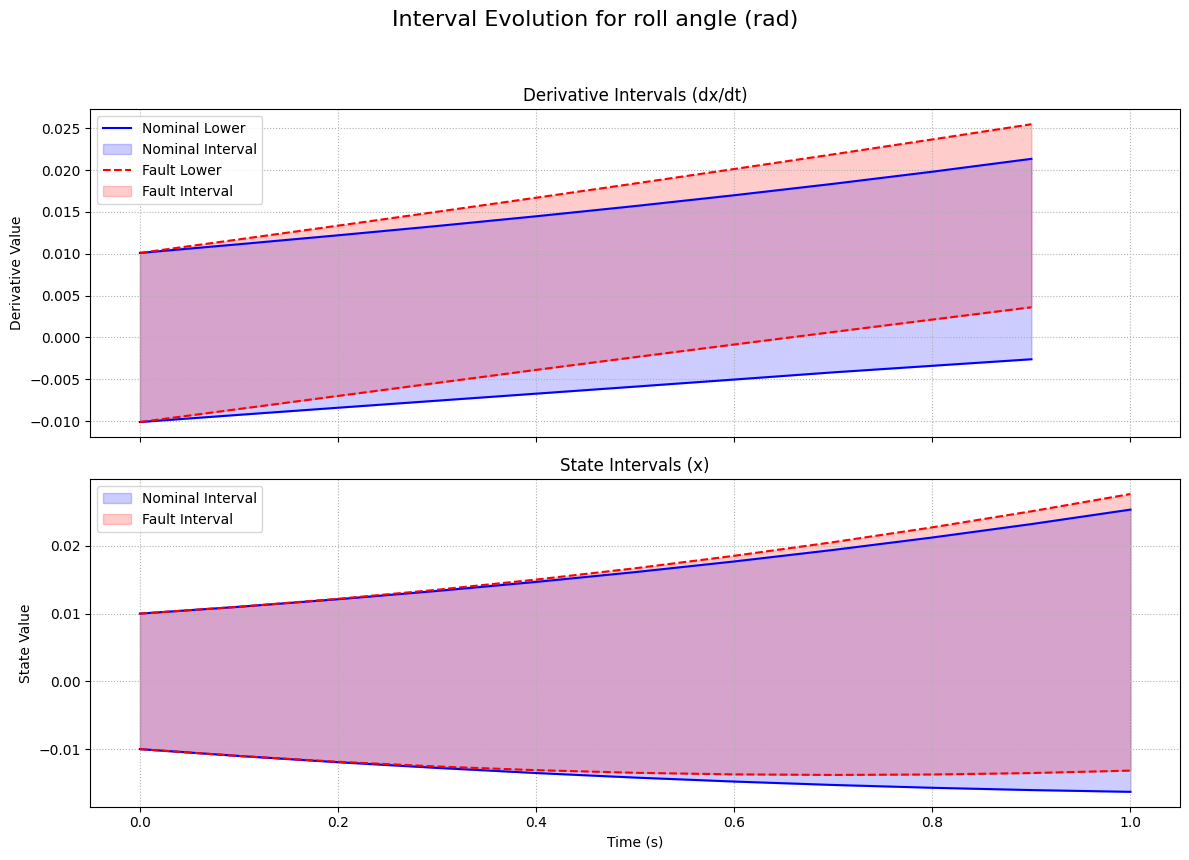

In [35]:
history_data = plot_intervals_euler_admire(
        u_ol=jnp.ones(admire.ulen) * 0.01,
        x_interval=x0_interval_admire,
        p_nominal=p_nominal_ivl,
        p_actuator_fault=p_yaw_tv_ivl,
        dt=0.1,
        num_steps=10
    )

Starting simulation for 10 steps...
Simulation finished. Preparing data for plotting...
Generating plots...


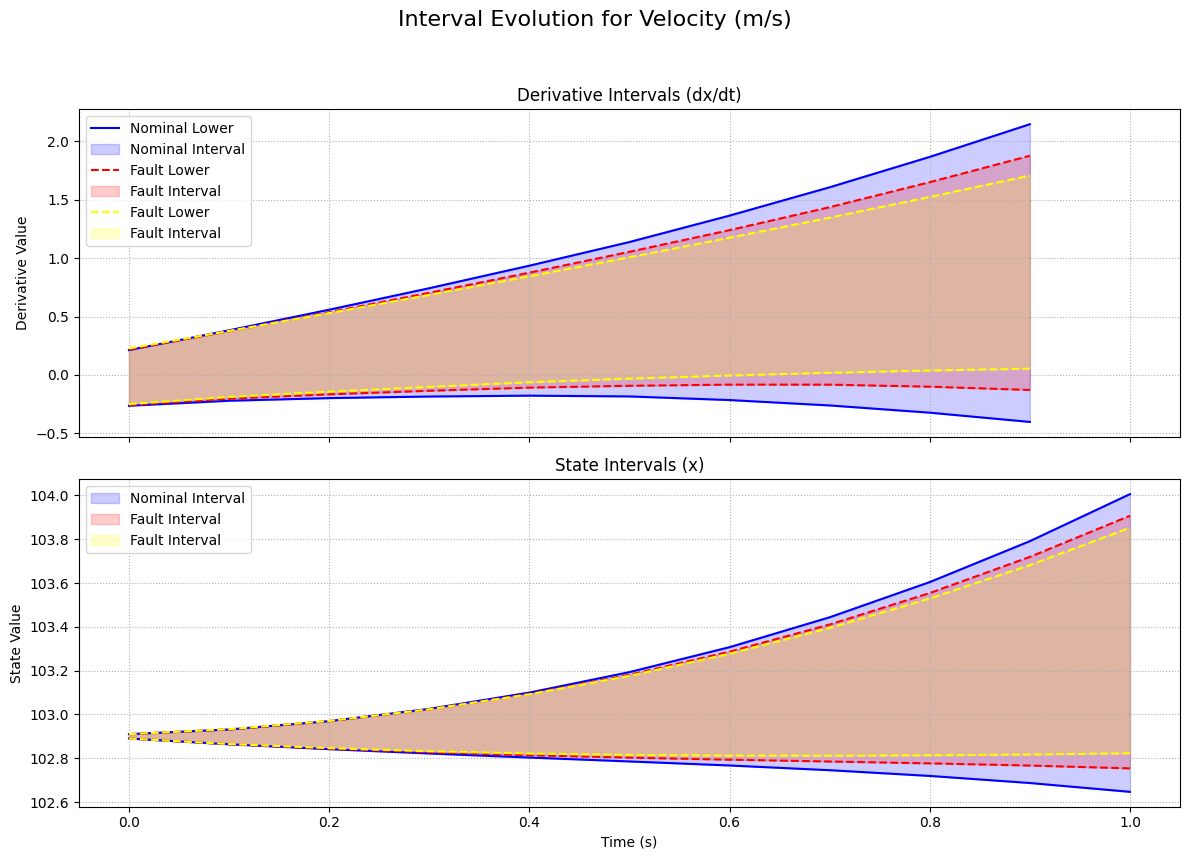

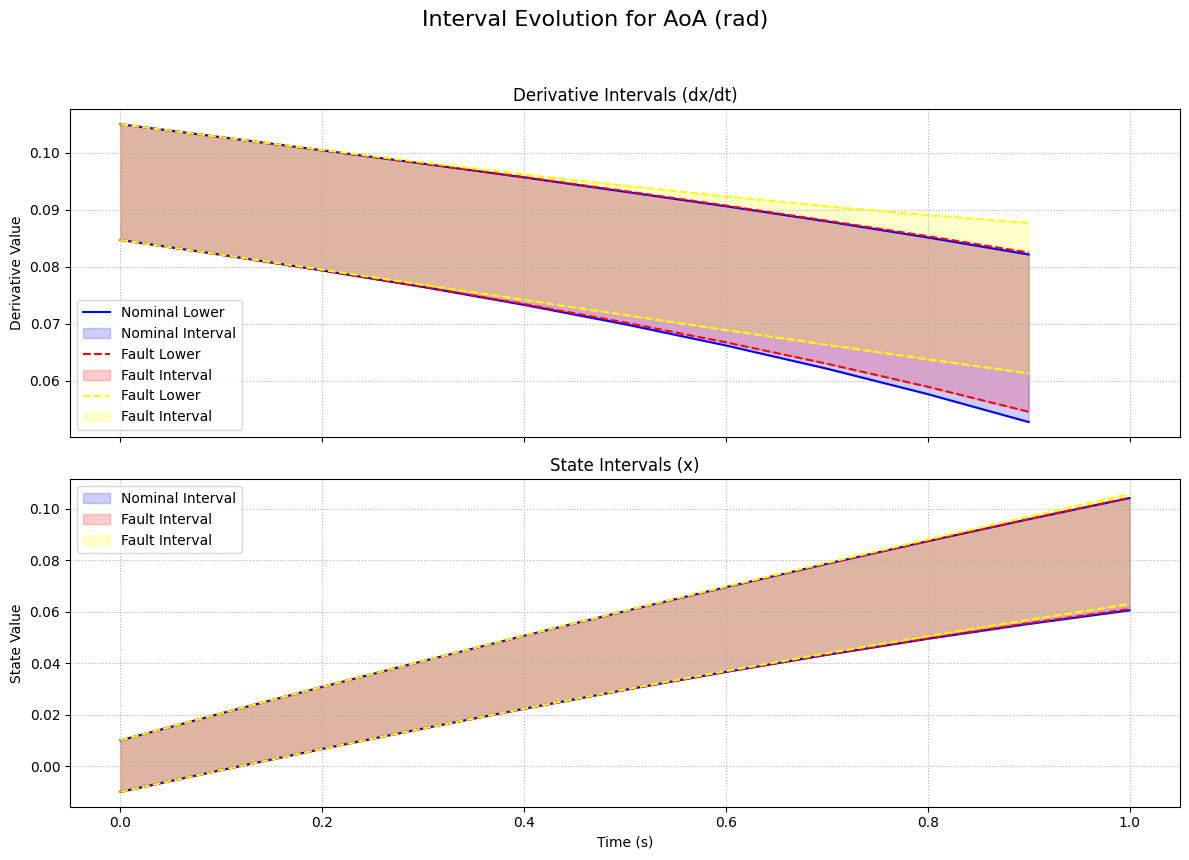

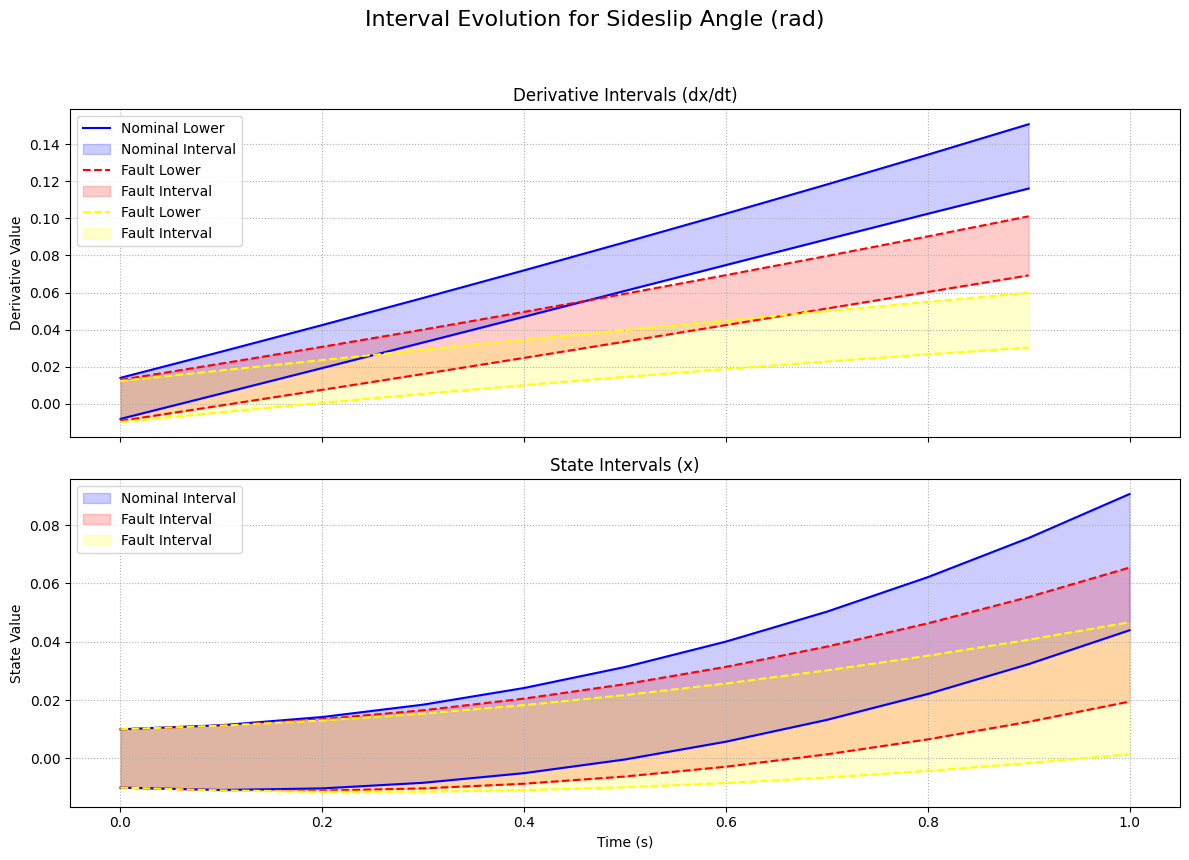

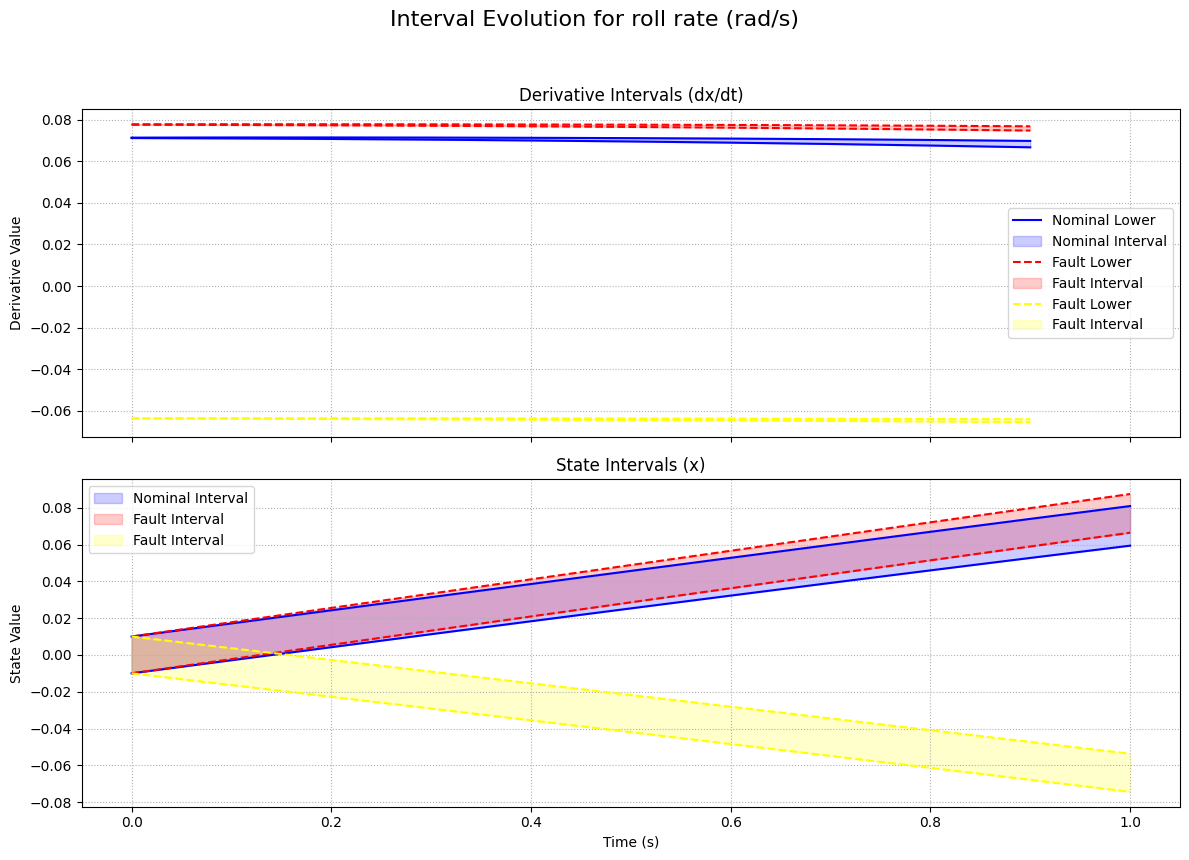

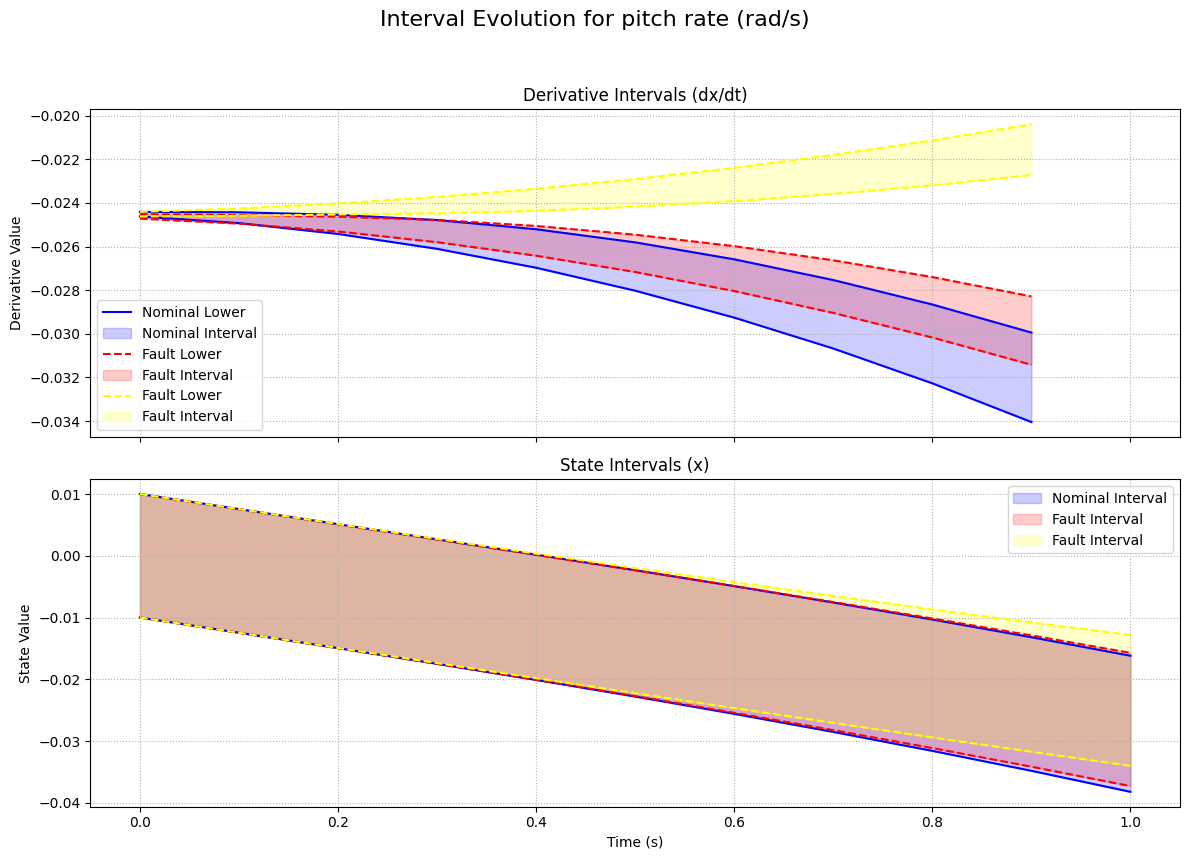

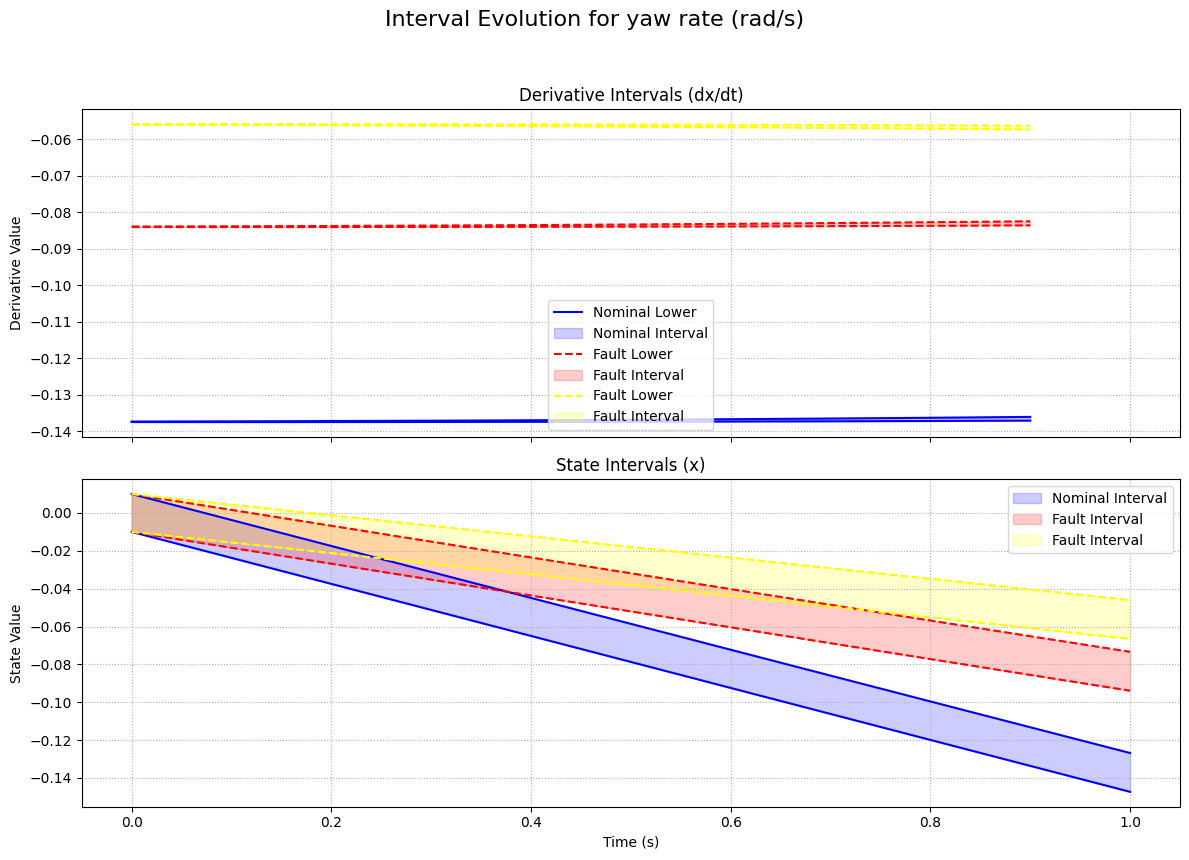

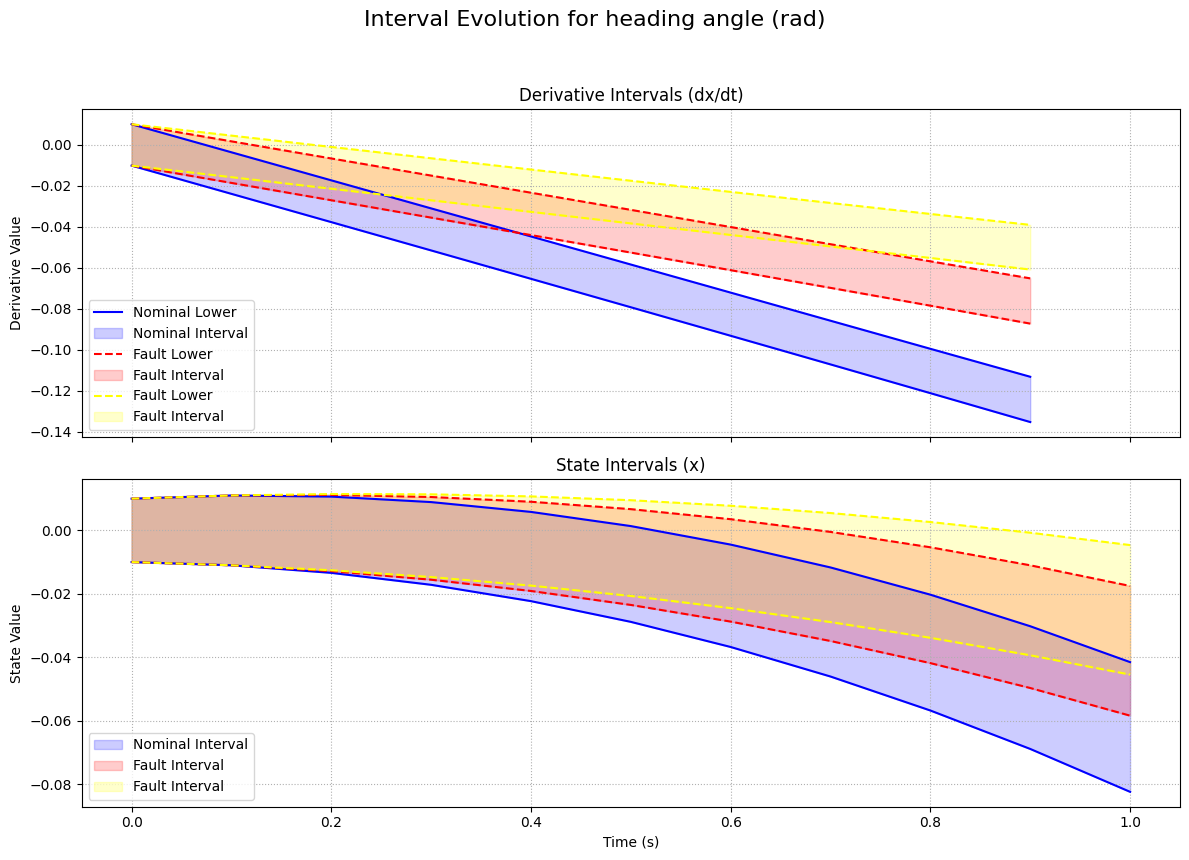

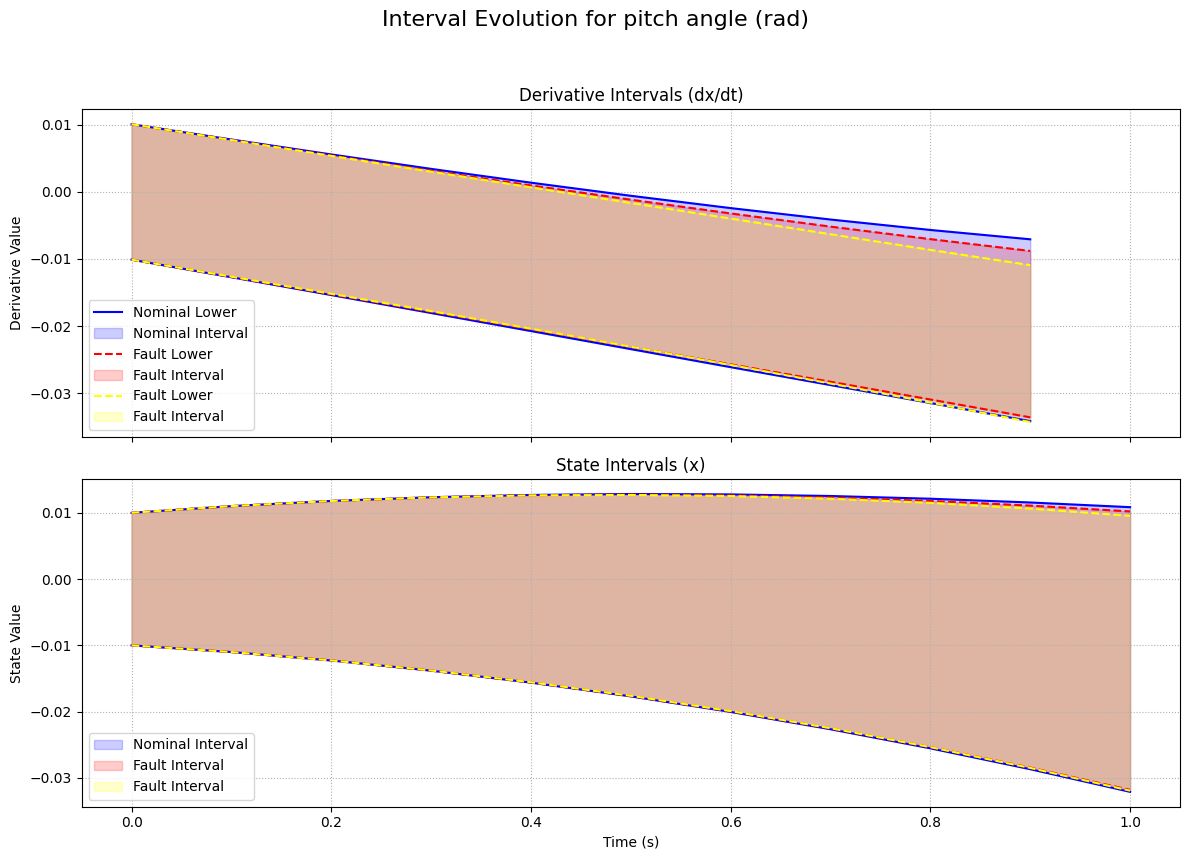

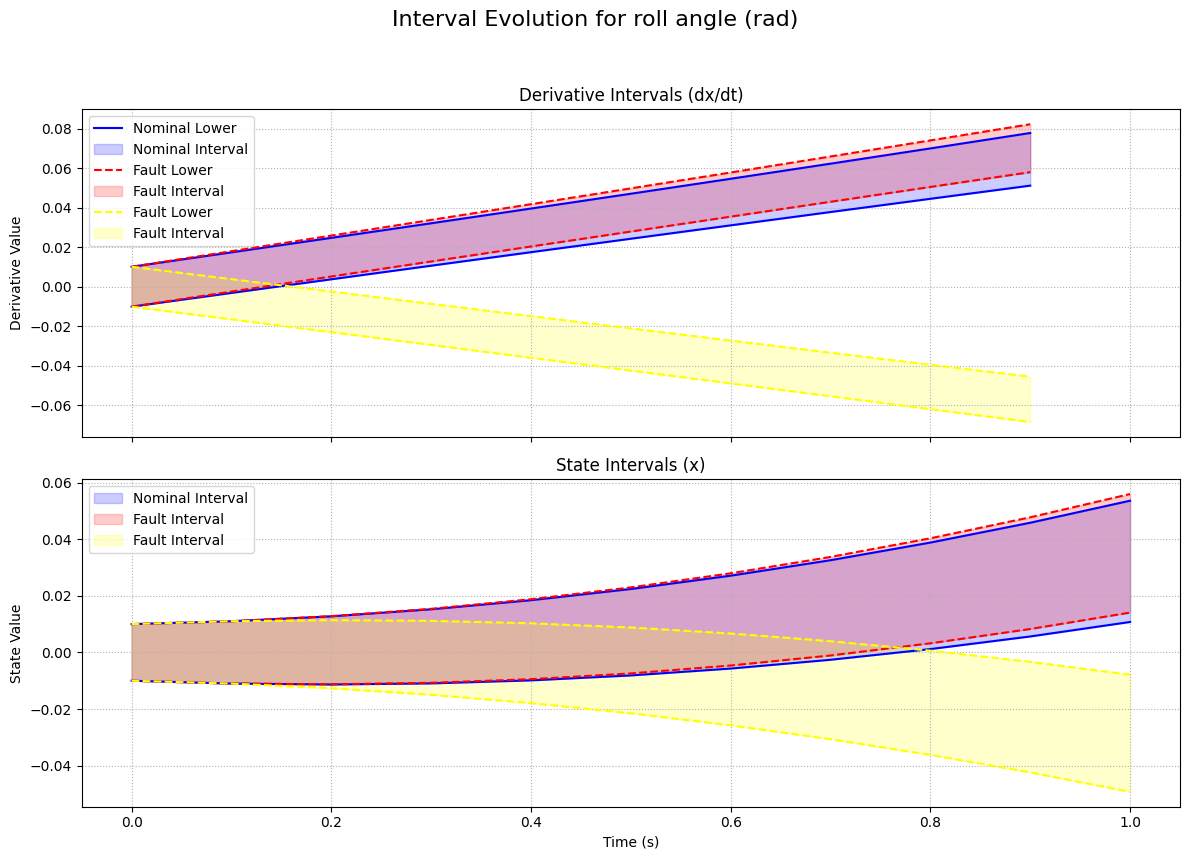

In [91]:
history_data_3faults = plot_intervals_euler_admire(
    u_ol = u,#jnp.array([0., 0., 0., 0., 0., 0., 0.01, 0., 0.001, 0.]),
    x_interval=x0_interval_admire,
    p_nominal=p_nominal_ivl,
    p_actuator_fault=p_yaw_tv_ivl,
    p_fault2=p_rudder_ivl,
    dt=0.1,
    num_steps=10
)